## Laplace filter analysis of two-point functions
This notebook reproduces the findings of [1].

[1] [Application of Laplace filters to the analysis of lattice time correlators, A Portelli and J T Tsang, Phys. Rev. D 112(9), 2025](https://doi.org/10.1103/3v93-9s9t).

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from scipy import stats

import latan
import latan.datasets.arXiv_2508_11541 as lf_paper
import latan.plot as lplt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Data loading

Download data

In [2]:
os.chdir(os.path.dirname(os.path.abspath("__file__")))
filename = lf_paper.download(".")

Data already downloaded


Load and bin all three two-point functions (M0M-mes-ll, F1M-mes-lh, and F1M-mes-hh)

In [3]:
data: dict[str, npt.NDArray] = {}
names = ["M0M-mes-ll", "F1M-mes-lh", "F1M-mes-hh"]
bin_sizes = [32, 24, 24]
for name, bin_size in zip(names, bin_sizes):
    print(f"==== {name}")
    data[name] = lf_paper.load_correlator(filename, name, verbose=True)
    data[name] = lf_paper.bin_correlator(data[name], bin_size, verbose=True)


==== M0M-mes-ll
nConf: 82
 nSrc: 64
   nt: 128
 size: 5248
 nBin: 164
==== F1M-mes-lh
nConf: 72
 nSrc: 48
   nt: 96
 size: 3456
 nBin: 144
==== F1M-mes-hh
nConf: 72
 nSrc: 48
   nt: 96
 size: 3456
 nBin: 144


## Improvement of time correlations (Sec. IV)

Naïve Gaussian mean and covariance

In [4]:
correlated_data: dict[str, latan.CorrelatedData] = {
    name: latan.make_correlated_data(corr) for name, corr in data.items()
}

Plot correlation matrices and CDRs (cf. Figs. 2 & 3)

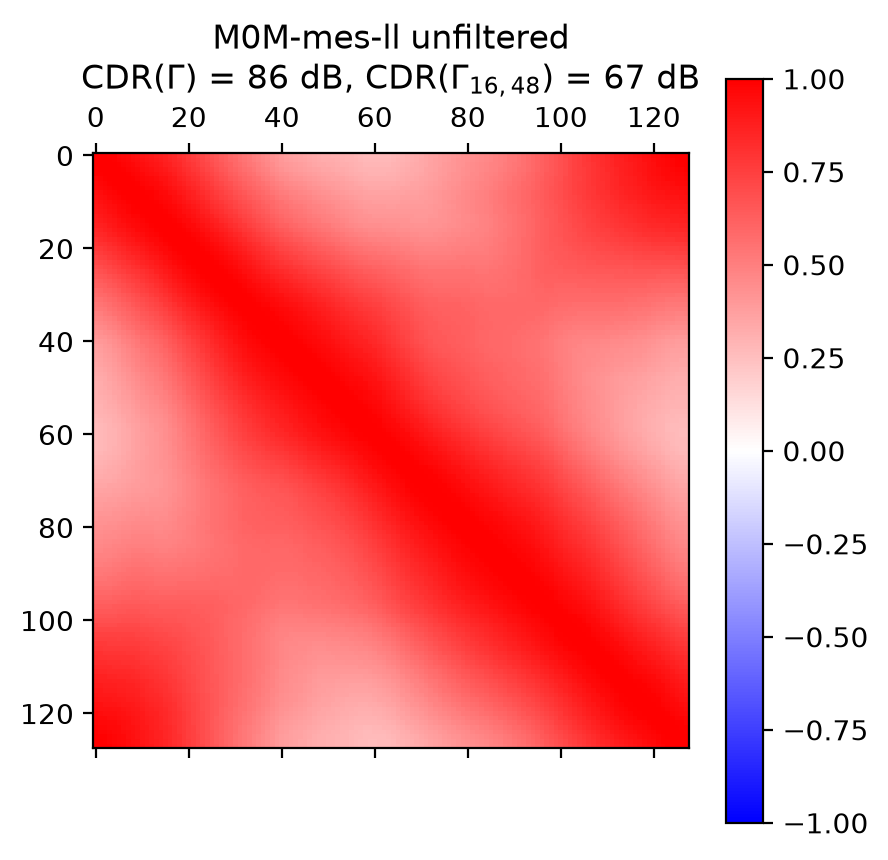

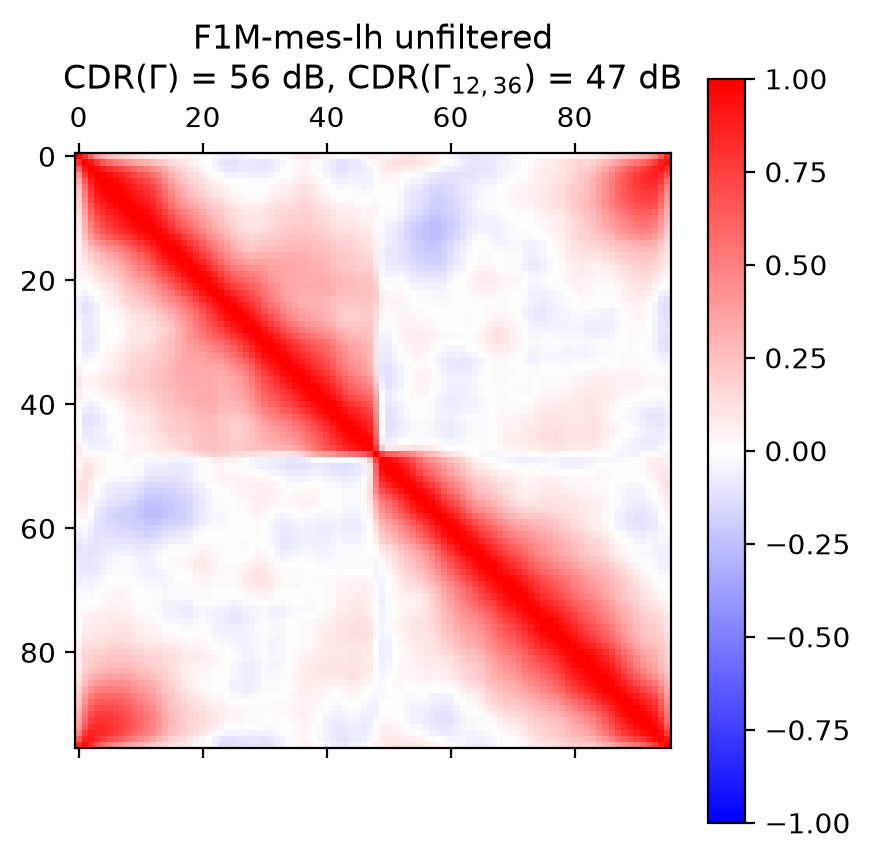

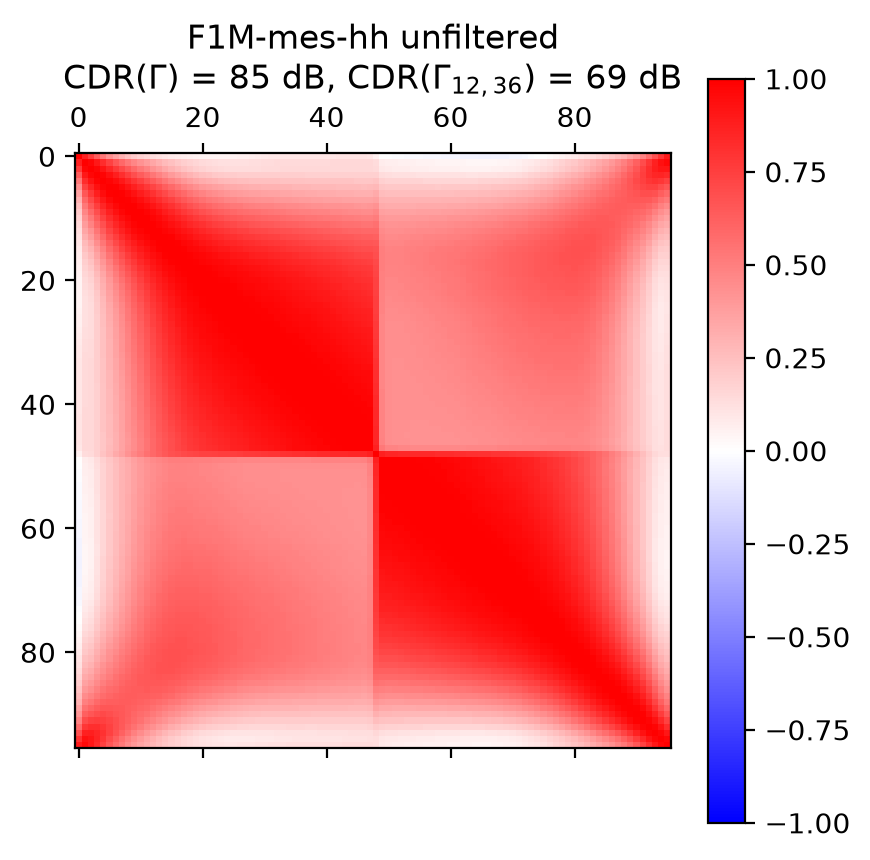

In [5]:
ranges = [(16, 48), (12, 36), (12, 36)]
for (name, corr), r in zip(data.items(), ranges):
    V = correlated_data[name].cov()
    Gamma, _ = latan.cov_to_corr(V)
    plt.matshow(Gamma, cmap="bwr", vmin=-1.0, vmax=1.0)
    title = f"{name} unfiltered\n"
    cdr = latan.cdr(Gamma)
    title += f"$\\mathrm{{CDR}}(\\Gamma)$ = {cdr:.0f} dB, "
    cdr = latan.cdr(Gamma[r[0] : r[1], r[0] : r[1]])
    title += f"$\\mathrm{{CDR}}(\\Gamma_{{{r[0]}, {r[1]}}})$ = {cdr:.0f} dB"
    plt.title(title)
    plt.colorbar()
    plt.show()

Plot the filtered CDRs as a function of the Laplace regulator (cf. Fig. 1)

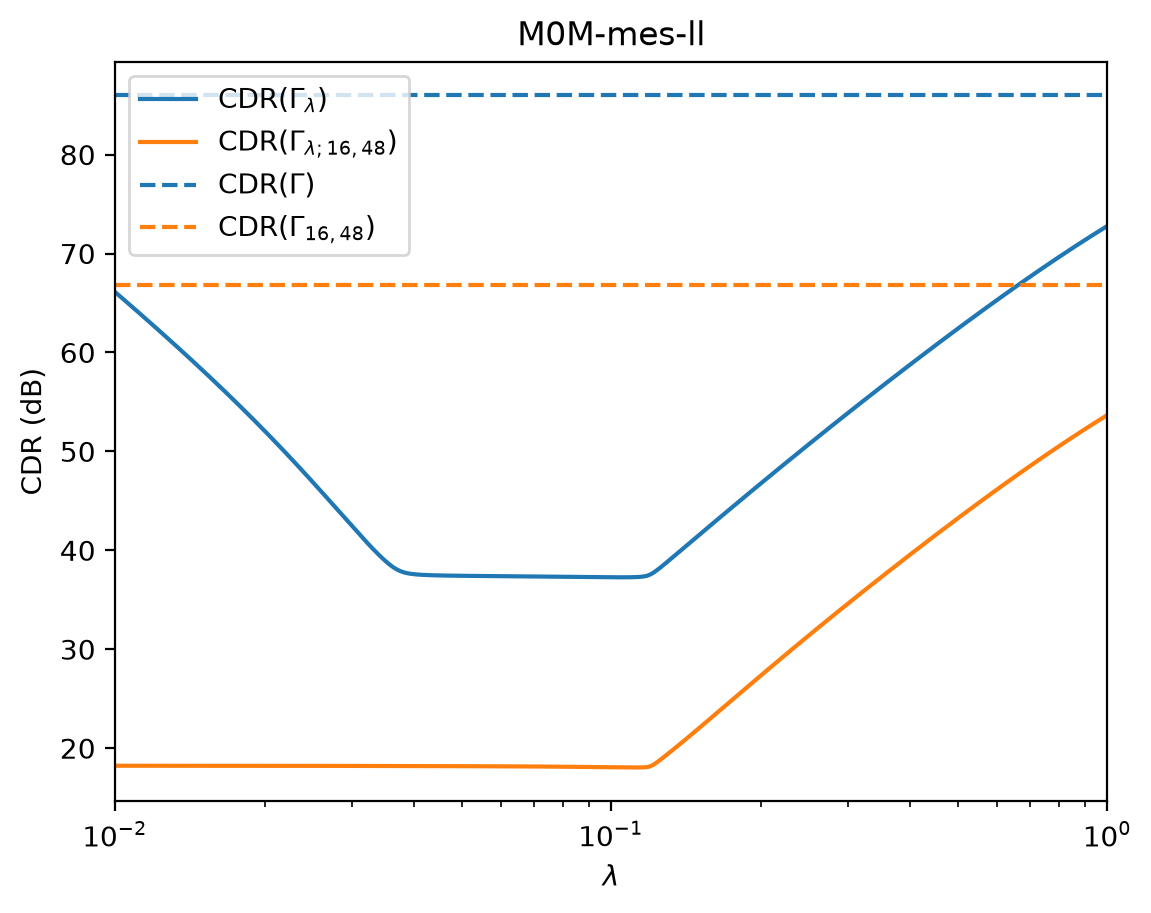

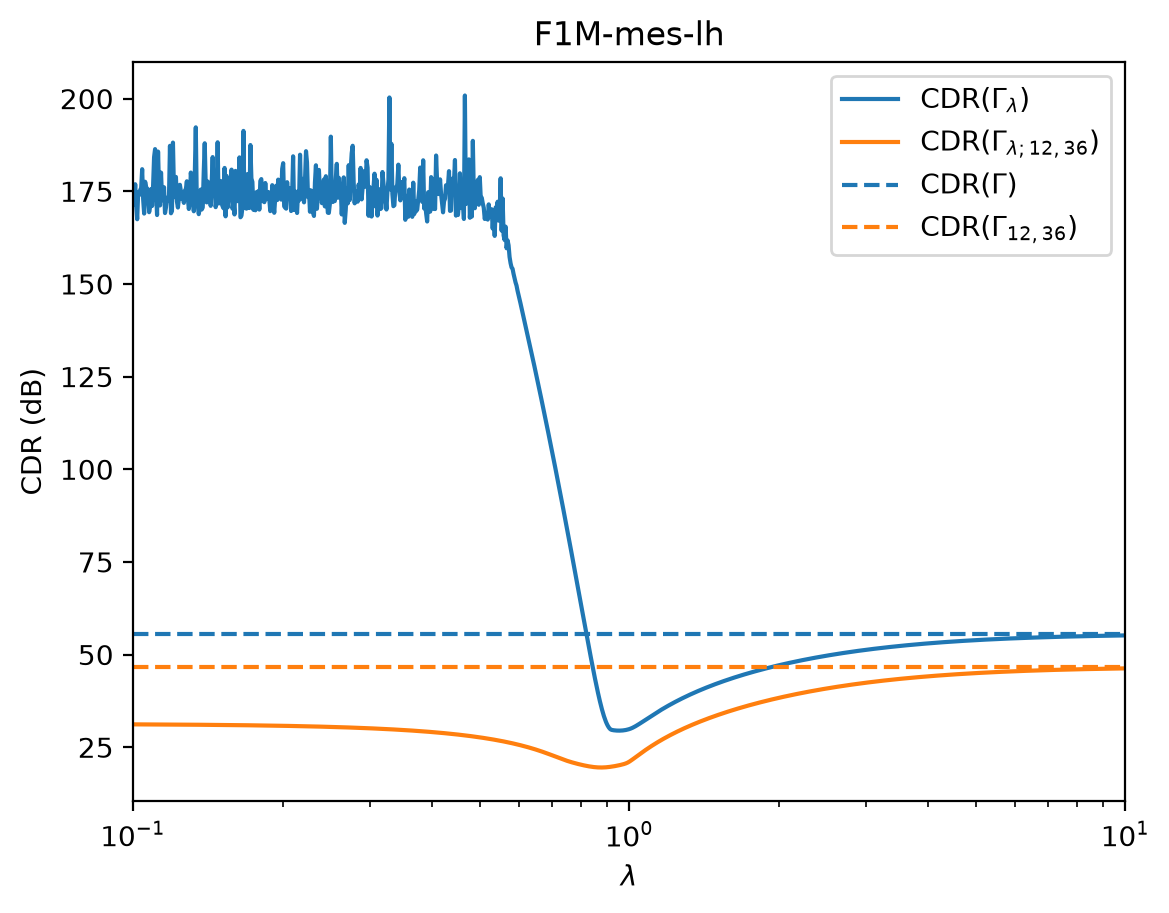

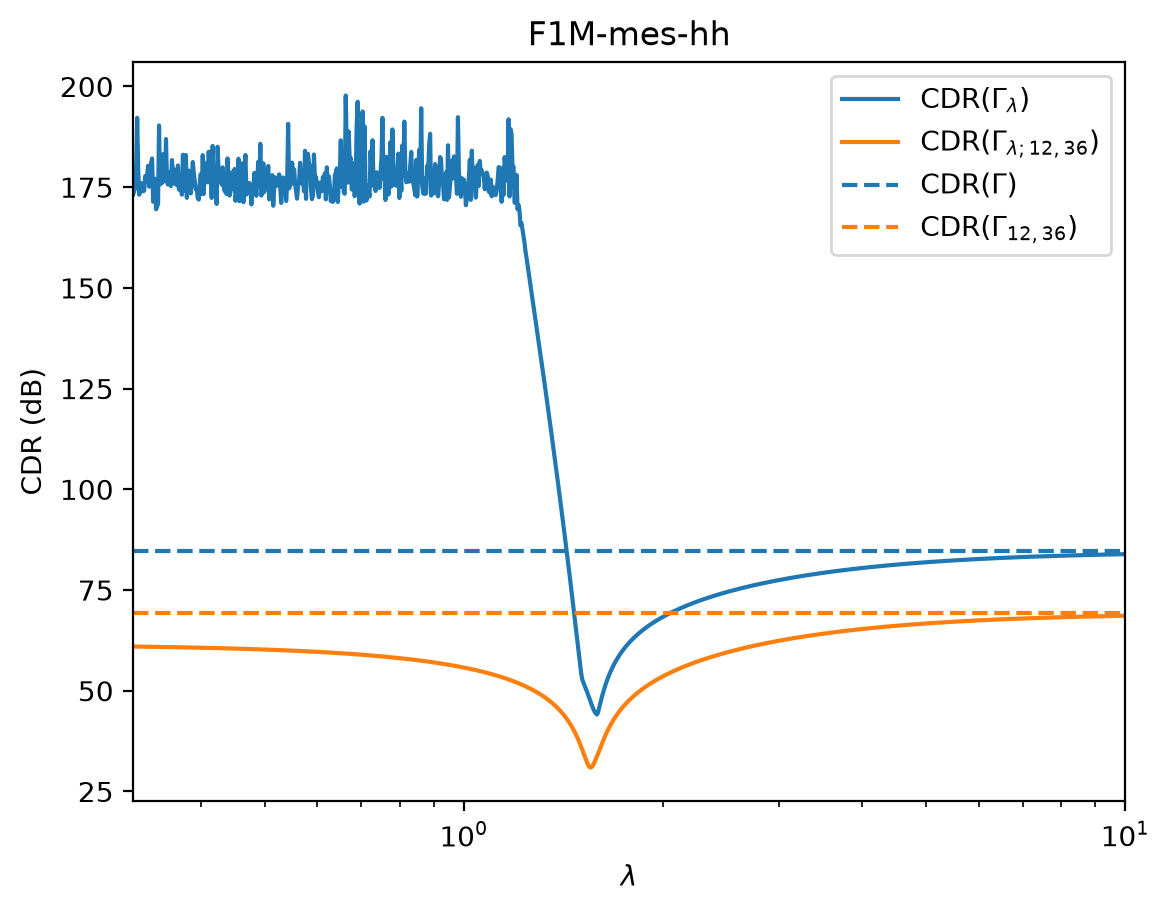

In [6]:
log_range = [(-2.0, 0.0), (-1.0, 1.0), (-0.5, 1.0)]
npts = 1000
for (name, corr), r, lr in zip(data.items(), ranges, log_range):
    V = correlated_data[name].cov()
    Gamma, _ = latan.cov_to_corr(V)
    cdr_ref = latan.cdr(Gamma)
    cdr_range_ref = latan.cdr(Gamma[r[0] : r[1], r[0] : r[1]])
    lambs = np.logspace(lr[0], lr[1], npts)
    cdr = np.empty(npts)
    cdr_range = np.empty(npts)
    for i in range(npts):
        Vf = latan.lfilter(V, lambs[i], dim=(0, 1))
        Gammaf, _ = latan.cov_to_corr(Vf)
        cdr[i] = latan.cdr(Gammaf)
        cdr_range[i] = latan.cdr(Gammaf[r[0] : r[1], r[0] : r[1]])
    plt.plot(lambs, cdr, label=r"$\mathrm{CDR}(\Gamma_\lambda)$")
    plt.plot(
        lambs, cdr_range, label=rf"$\mathrm{{CDR}}(\Gamma_{{\lambda;{r[0]}, {r[1]}}})$"
    )
    plt.axhline(
        cdr_ref,
        0.0,
        lambs[-1],
        color="C0",
        linestyle="--",
        label=r"$\mathrm{CDR}(\Gamma)$",
    )
    plt.axhline(
        cdr_range_ref,
        0.0,
        lambs[-1],
        color="C1",
        linestyle="--",
        label=f"$\\mathrm{{CDR}}(\\Gamma_{{{r[0]}, {r[1]}}})$",
    )
    plt.xlim(lambs[0], lambs[-1])
    plt.xscale("log")
    plt.xlabel(r"$\lambda$")
    plt.ylabel(r"$\mathrm{CDR}~(\mathrm{dB})$")
    plt.legend()
    plt.title(name)
    plt.show()

Minimise CDR vs. $\lambda$ and improved correlation matrix (cf. Fig. 2 & 3)

==== M0M-mes-ll
global lambda_opt = 0.1043
 range lambda_opt = 0.1115


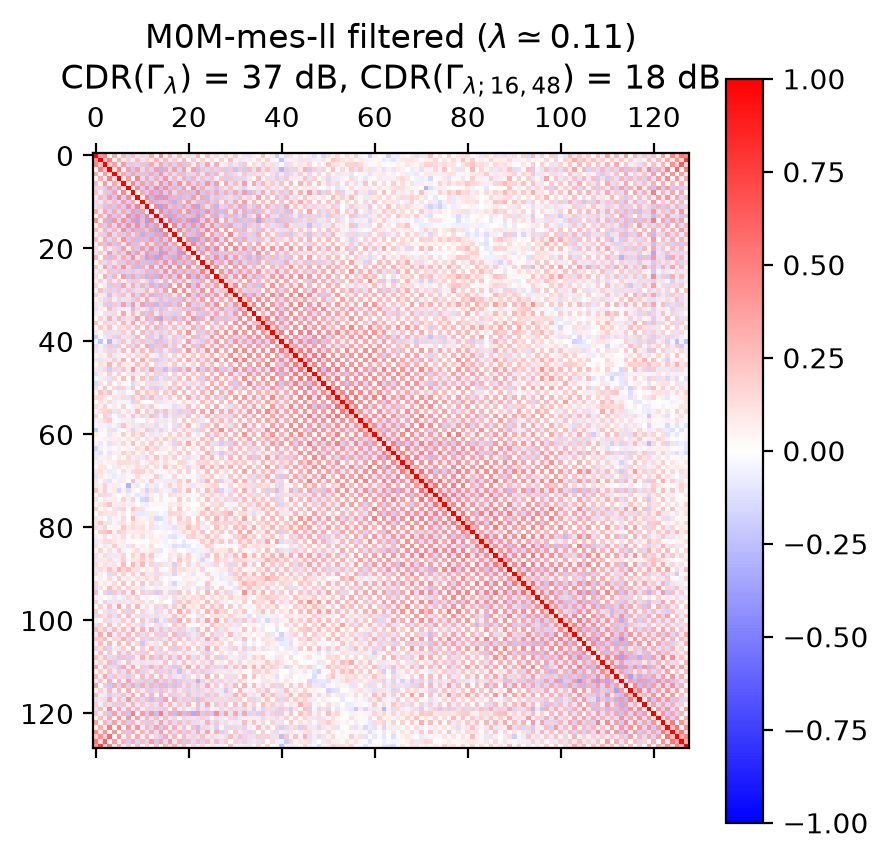

==== F1M-mes-lh
global lambda_opt = 0.9534
 range lambda_opt = 0.8774


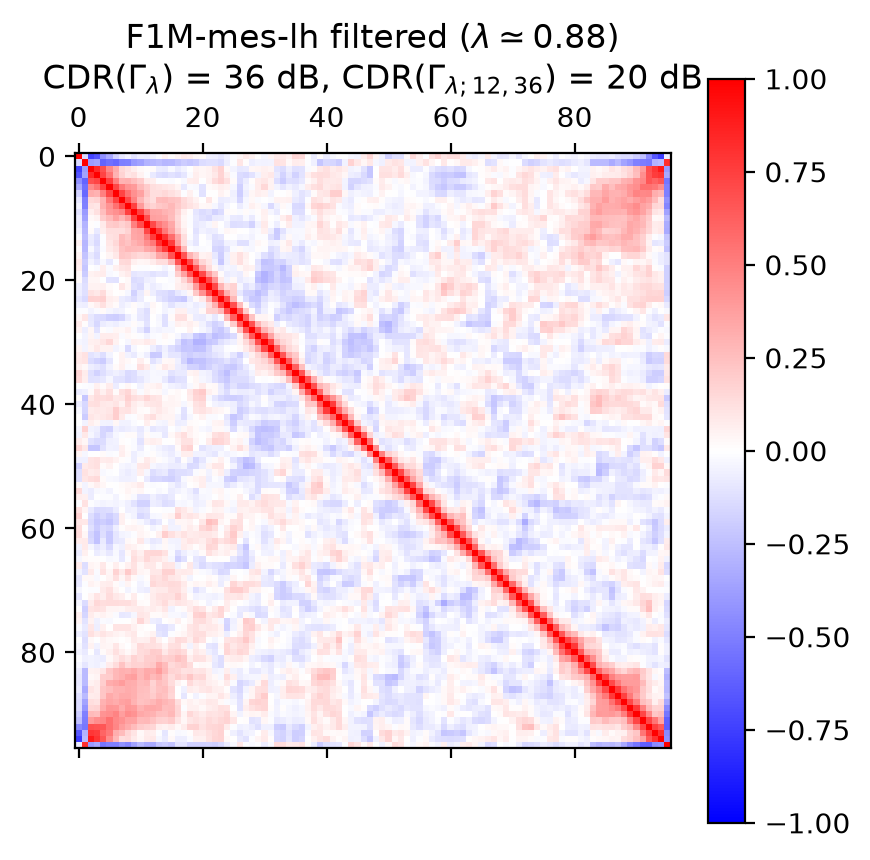

==== F1M-mes-hh
global lambda_opt = 1.5902
 range lambda_opt = 1.5543


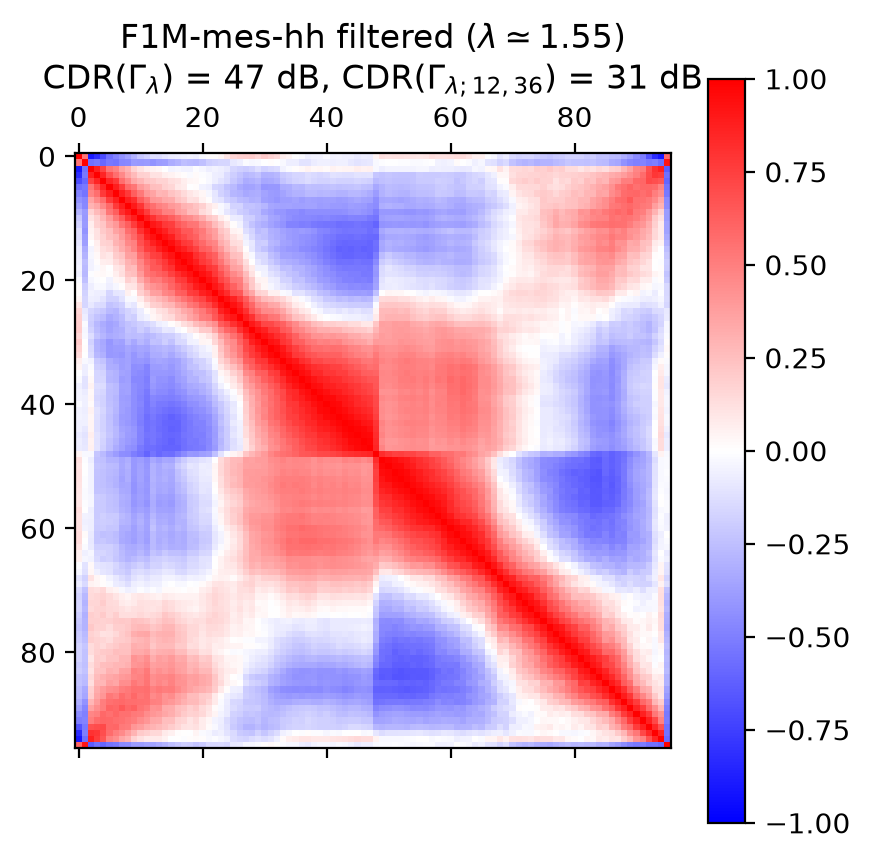

In [7]:
for (name, corr), r in zip(data.items(), ranges):
    print(f"==== {name}")
    V = correlated_data[name].cov()
    lamb_opt = latan.lfilter_optimize_cdr(V)
    lamb_opt_range = latan.lfilter_optimize_cdr(V, r)
    print(f"global lambda_opt = {lamb_opt:.4f}")
    print(f" range lambda_opt = {lamb_opt_range:.4f}")
    Vf = latan.lfilter(V, lamb_opt_range, dim=(0, 1))
    Gammaf, _ = latan.cov_to_corr(Vf)
    plt.matshow(Gammaf, cmap="bwr", vmin=-1.0, vmax=1.0)
    title = f"{name} filtered ($\\lambda\\simeq {lamb_opt_range:.2f}$)\n"
    cdr = latan.cdr(Gammaf)
    title += f"$\\mathrm{{CDR}}(\\Gamma_\\lambda)$ = {cdr:.0f} dB, "
    cdr = latan.cdr(Gammaf[r[0] : r[1], r[0] : r[1]])
    title += f"$\\mathrm{{CDR}}(\\Gamma_{{\\lambda;{r[0]}, {r[1]}}})$ = {cdr:.0f} dB"
    plt.title(title)
    plt.colorbar()
    plt.show()


## Spectral effect of Laplace filters (Sec. V)

Helper functions for the $\chi^2$ $p$-value.

In [8]:
def pval(t2: latan.LaplaceFilteredT2, lambs: npt.NDArray) -> float:
    r = t2.ranges[0]
    dof = r[1] - r[0]
    return (1 - stats.chi2.cdf(t2(lambs), dof)).item()

Helper function for the $p$-value contour plots in Fig. 6 & 7.

In [9]:
def plot_2x2_pvalue(
    name: str,
    tis: tuple[int, int, int, int],
    tf: int,
    e0: tuple[float, float],
    e1: tuple[float, float],
    n_points: int,
):
    x = latan.lfilter_tilde(np.linspace(e0[0], e0[1], n_points))
    y = latan.lfilter_tilde(np.linspace(e1[0], e1[1], n_points))
    X, Y = np.meshgrid(x, y)
    E0, E1 = latan.lfilter_tilde_inv(X), latan.lfilter_tilde_inv(Y)
    points = np.stack((X.ravel(), Y.ravel()), axis=1)
    fig, axes = plt.subplots(
        2, 2, figsize=(8, 7), sharex=True, sharey=True, constrained_layout=True
    )
    current_data = correlated_data[name]
    for ax, ti in zip(axes.flat, tis):
        t2 = latan.LaplaceFilteredT2(current_data, [(ti, tf)])
        Z = np.array([pval(t2, point) for point in points]).reshape(X.shape)
        _, _, image = lplt.pvalue_contour(E0, E1, Z, ax=ax)
        ax.text(
            0.03, 0.97, rf"$t_i = {ti}$", transform=ax.transAxes, ha="left", va="top"
        )
        ax.set(xlabel="$E_0$", ylabel="$E_1$")
        ax.set_box_aspect(1)
        ax.locator_params(axis="x", nbins=5)
        fig.colorbar(image, ax=ax, ticks=np.linspace(0.0, 1.0, 11), format="%.1f")

Reproduction of Fig. 6

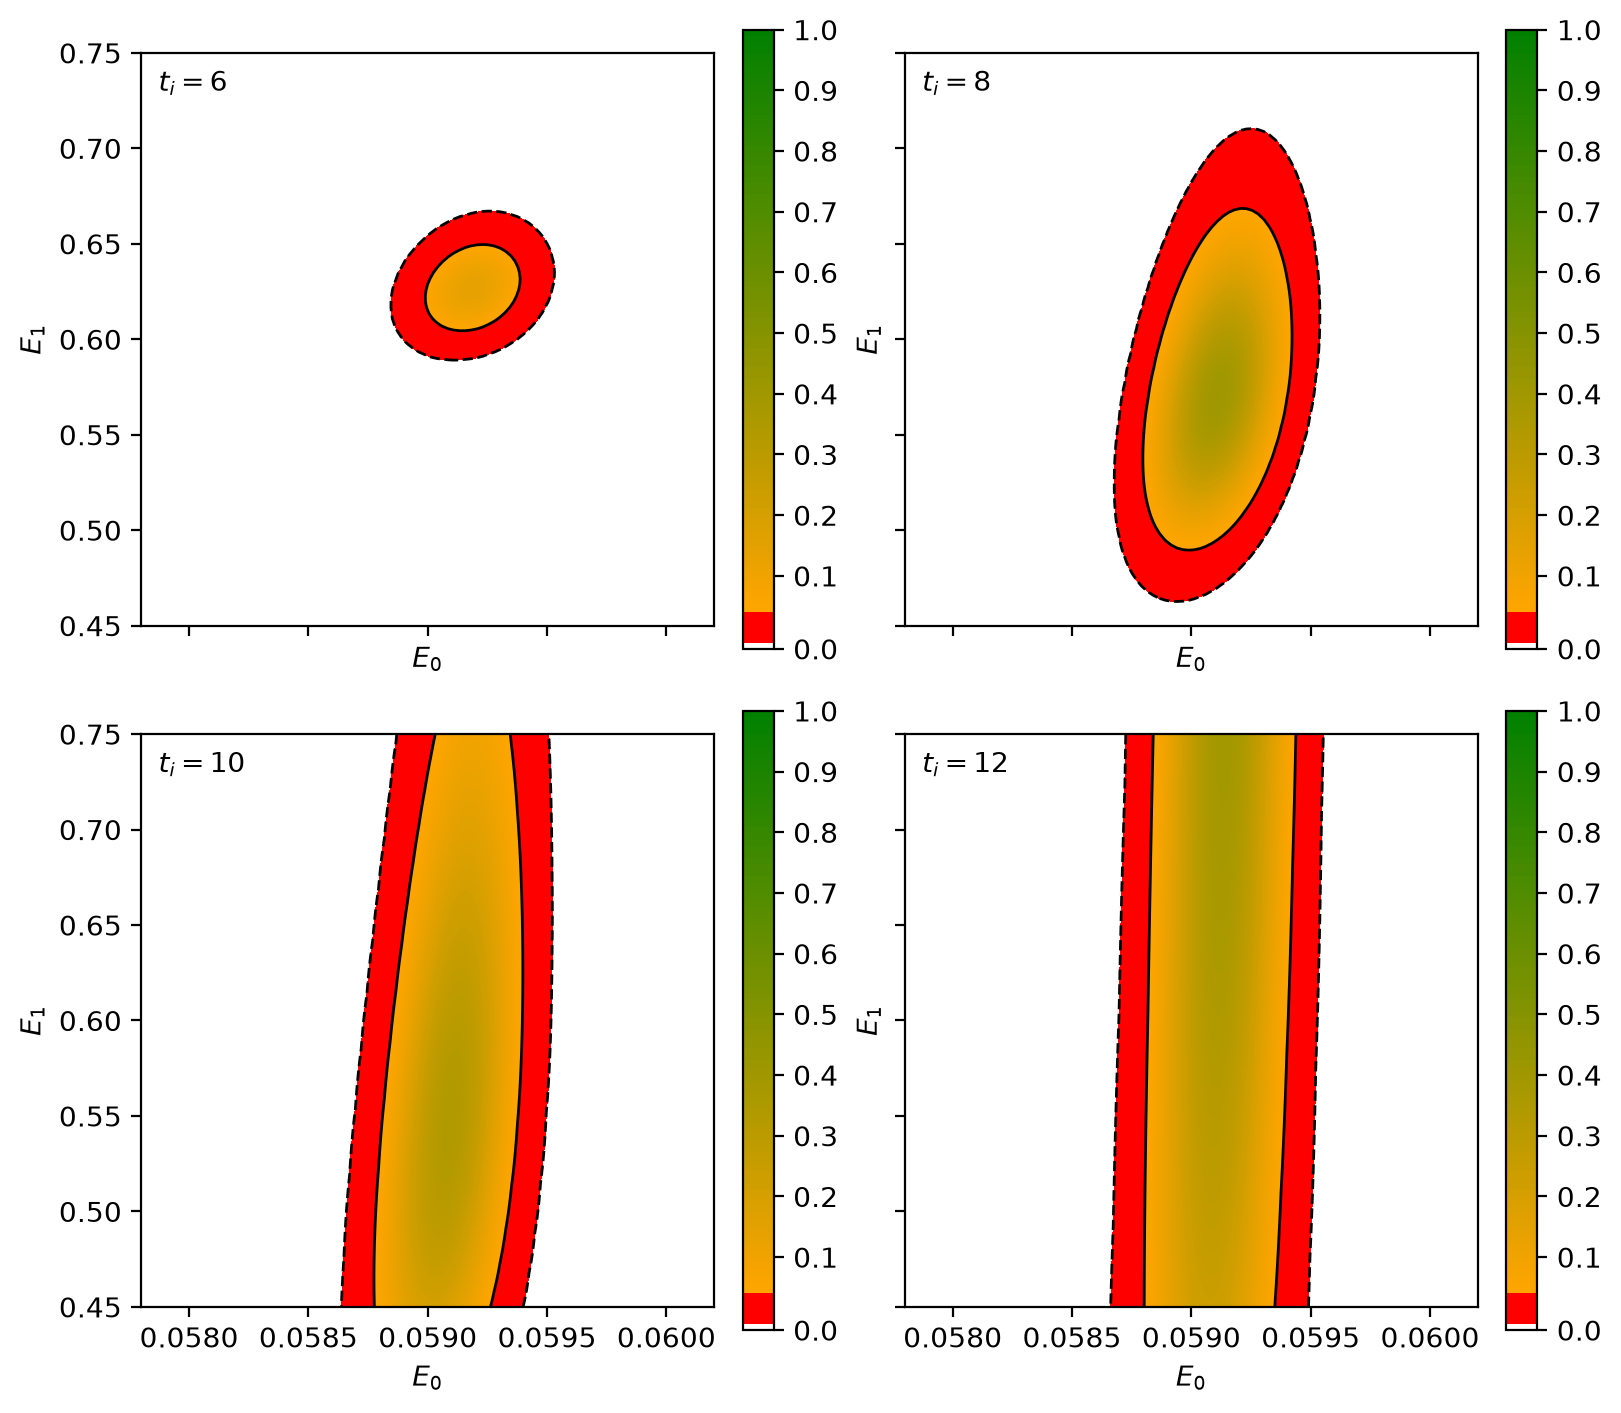

In [10]:
name = "M0M-mes-ll"
tis = (6, 8, 10, 12)
tf = 48
n_points = 100
e0 = (0.0578, 0.0602)
e1 = (0.45, 0.75)
plot_2x2_pvalue(name, tis, tf, e0, e1, n_points)
plt.show()

Reproduction of Fig. 7

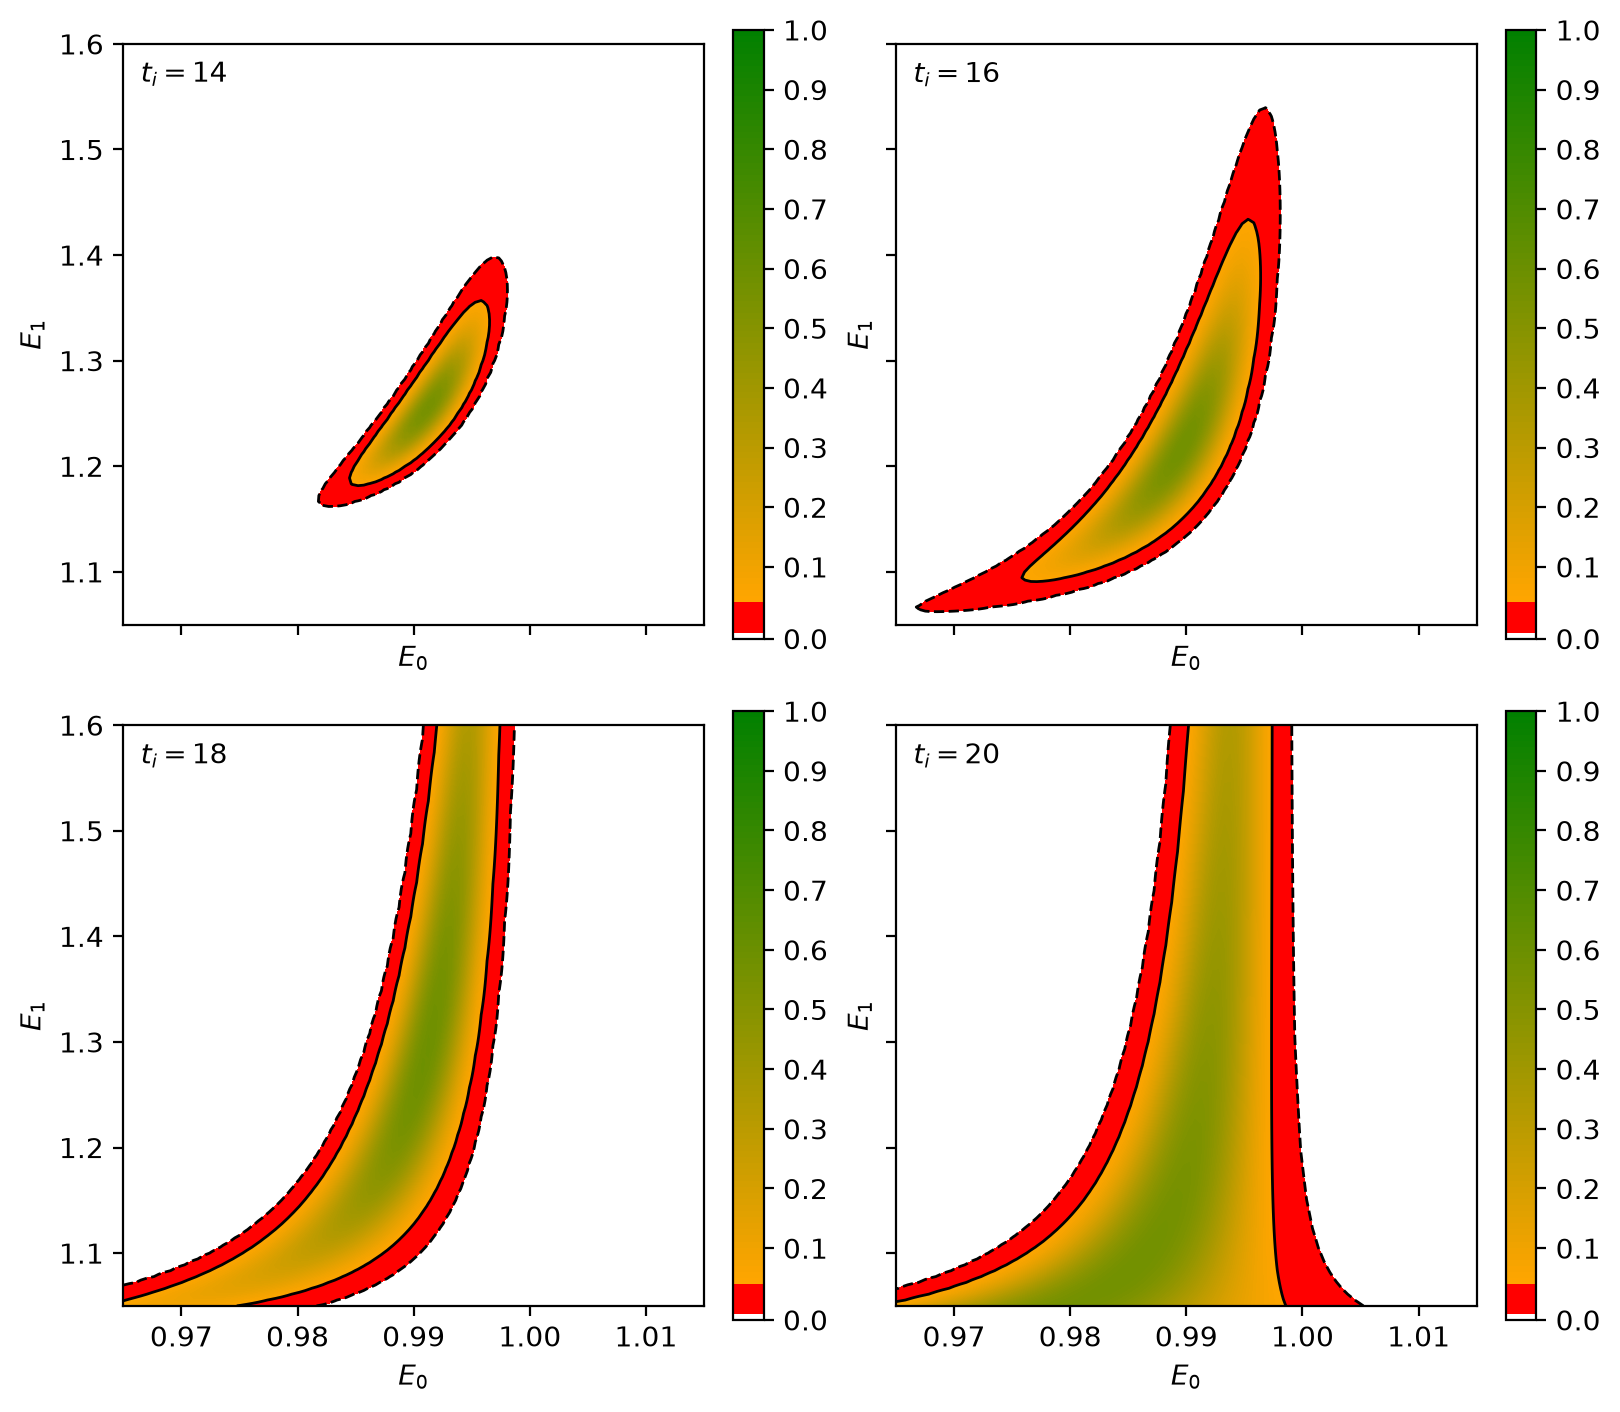

In [11]:
name = "F1M-mes-lh"
tis = (14, 16, 18, 20)
tf = 36
n_points = 100
e0 = (0.965, 1.015)
e1 = (1.05, 1.6)
plot_2x2_pvalue(name, tis, tf, e0, e1, n_points)
plt.show()

Laplace filter F1M-mes-hh spectrum determination in verbose mode

In [12]:
spectrum_data = correlated_data["F1M-mes-hh"]
spec = latan.lfilter_spectrum_test(
    spectrum_data, [(8, 36)], n_state=5, alpha=0.05, verbose=True
)
print(f"spectrum: {spec.spectra[spec.sig_states - 1].energies}")

==== Laplace filter spectrum -- ranges = [8, 36)
1 states: T^2_1 = 3.21e+06 (p_1 = 0.00e+00), Lambda = [1.77405082]
2 states: T^2_2 = 3.45e+04 (p_2 = 0.00e+00), ΔT^2_1 = 3.17e+06 (pb_1 = 0.00e+00), Lambda = [1.631359   2.20210507]
3 states: T^2_3 = 5.05e+02 (p_3 = 7.67e-91), ΔT^2_2 = 3.40e+04 (pb_2 = 0.00e+00), Lambda = [1.62239532 2.01488192 2.63494362]
4 states: T^2_4 = 2.21e+01 (p_4 = 5.72e-01), ΔT^2_3 = 4.83e+02 (pb_3 = 0.00e+00), Lambda = [1.62209005 1.95136771 2.36689258 3.40755073]
5 states: T^2_5 = 2.20e+01 (p_5 = 5.20e-01), ΔT^2_4 = 1.20e-01 (pb_4 = 7.29e-01), Lambda = [1.62208258 1.94963551 2.35831051 3.34529815 7.00611942]
Holm-Bonferroni rejections: H1 H2 H3 -- H4 not rejected, 4 sigificant states
spectrum: [1.48253951 1.72814906 2.01066484 2.60546607]


Reproduction of Fig. 8

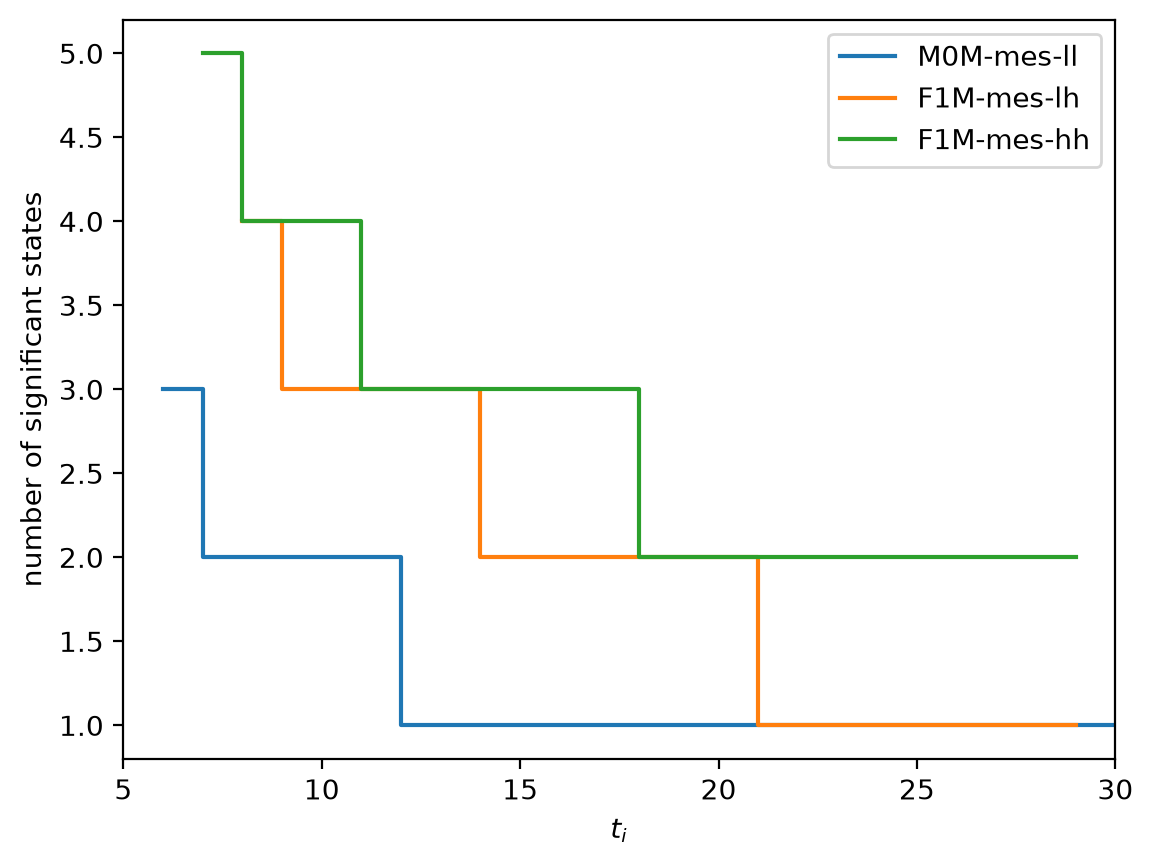

In [13]:
for (name, corr), r in zip(data.items(), ranges):
    spectrum_data = correlated_data[name]
    sig_state = []
    tis = []
    for ti in range(6, r[1] - 6):
        spec = latan.lfilter_spectrum_test(
            spectrum_data, [(ti, r[1])], n_state=5, alpha=0.05
        )
        if spec.sig_states > 0:
            tis.append(ti)
            sig_state.append(spec.sig_states)
    plt.step(tis, sig_state, label=name, where="post")
plt.xlim(5, 30)
plt.xlabel(r"$t_i$")
plt.ylabel("number of significant states")
plt.legend()
plt.show()